# Airbnb Europe Pricing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns              

df = pd.read_csv('../airbnb/data/clean_data/airbnb_cleaned.csv')
df.shape

(48045, 21)

## Exploratory Data Analysis

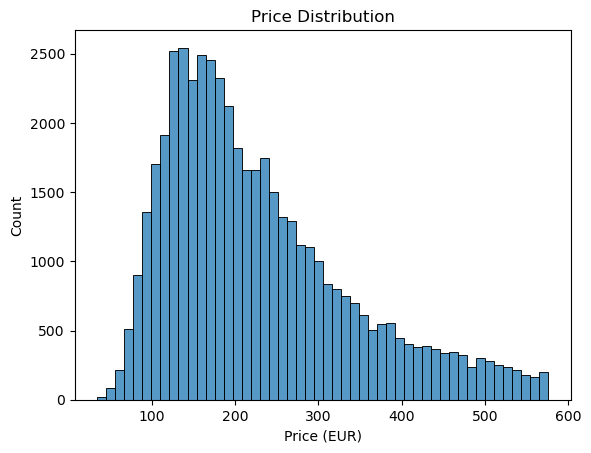

In [4]:
# price distribution
# each chart is saved to img folder
plt.figure()
sns.histplot(df['realSum'], bins=50)  
plt.title('Price Distribution')
plt.xlabel('Price (EUR)')
plt.savefig('../airbnb/img/price_distribution.png')  
plt.show()

Most listings are priced between roughly €80 and €300

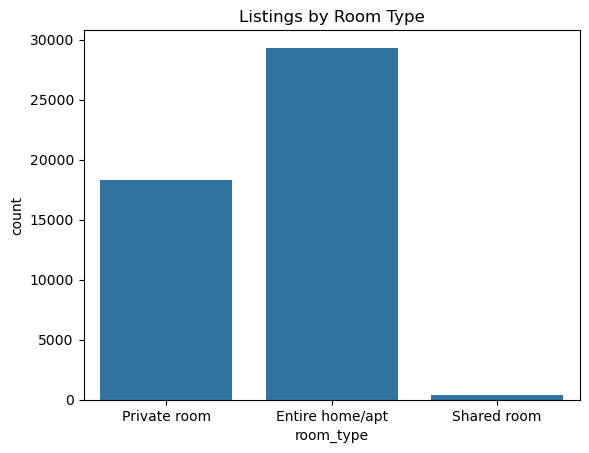

In [5]:
# room type distribution
plt.figure()
sns.countplot(data=df, x='room_type')
plt.title('Listings by Room Type')
plt.savefig('../airbnb/img/room_type_distribution.png')
plt.show()

Entire homes/apartments make up most of the listings, followed by private rooms

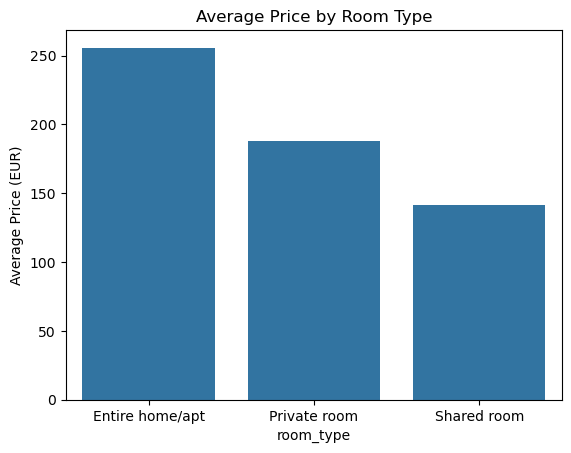

In [6]:
#avg price by room type
avg_price = df.groupby('room_type')['realSum'].mean()

plt.figure()
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Room Type')
plt.ylabel('Average Price (EUR)')
plt.savefig('../airbnb/img/avg_price_by_room_type.png')
plt.show()

Entire homes are the most expensive on average, private rooms are in the middle, shared rooms are cheapest.

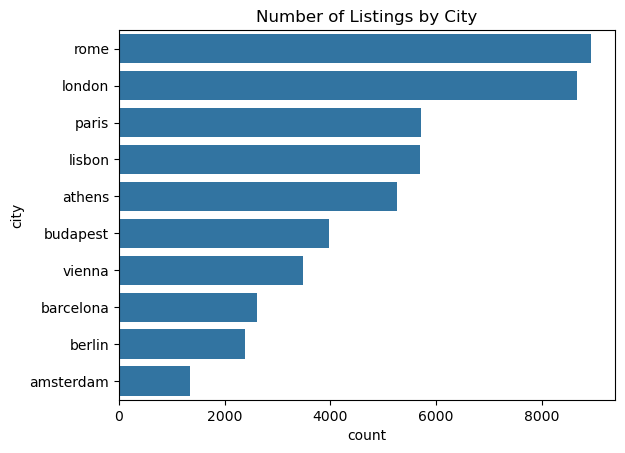

In [7]:
# count by city
plt.figure()
sns.countplot(data=df, y='city', order=df['city'].value_counts().index)
plt.title('Number of Listings by City')
plt.savefig('../airbnb/img/listings_by_city.png')
plt.show()

Rome, London, and Paris have the most listings in this dataset.

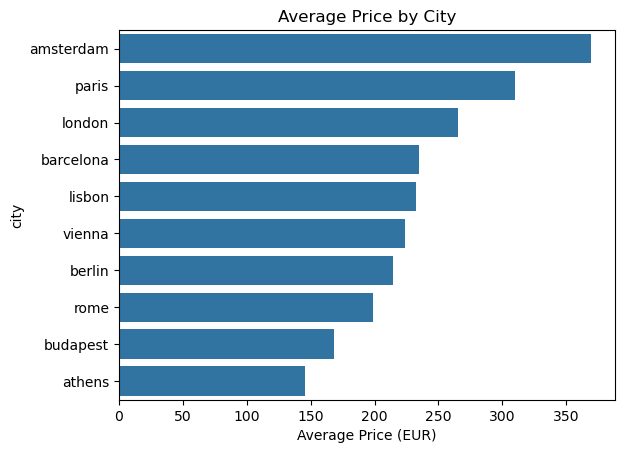

In [8]:
#avg prive by city
city_price = df.groupby('city')['realSum'].mean().sort_values(ascending=False)
plt.figure()
sns.barplot(x=city_price.values, y=city_price.index)
plt.title('Average Price by City')
plt.xlabel('Average Price (EUR)')
plt.savefig('../airbnb/img/avg_price_by_city.png')
plt.show()

Amsterdam and Paris are the most expensive cities on average while Athens and Budapest are the cheapest.

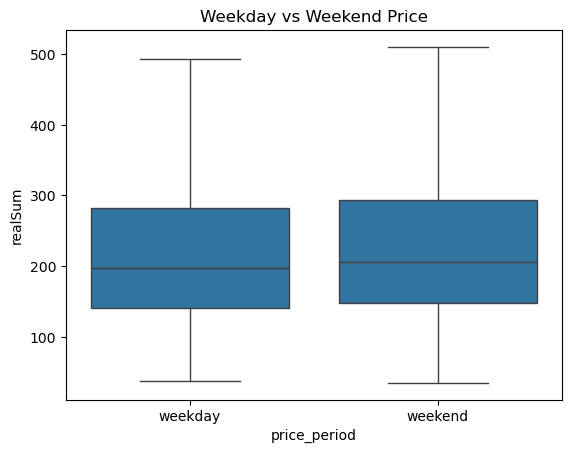

In [9]:
#price between weekday and weekend
plt.figure()
sns.boxplot(data=df, x='price_period', y='realSum', showfliers=False)
plt.title('Weekday vs Weekend Price')
plt.savefig('../airbnb/img/weekday_vs_weekend.png')
plt.show()

Weekend prices are a little higher on average, but the difference is small.

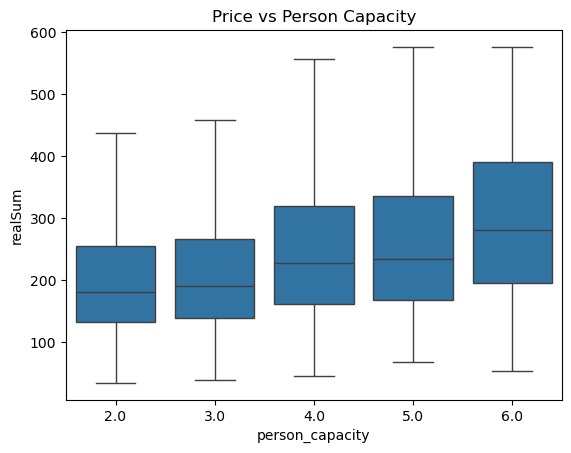

In [10]:
#price vs person capaacity
plt.figure()
sns.boxplot(data=df, x='person_capacity', y='realSum', showfliers=False)
plt.title('Price vs Person Capacity')
plt.savefig('../airbnb/img/price_vs_capacity.png')
plt.show()

Price goes up as the listing can host more guests

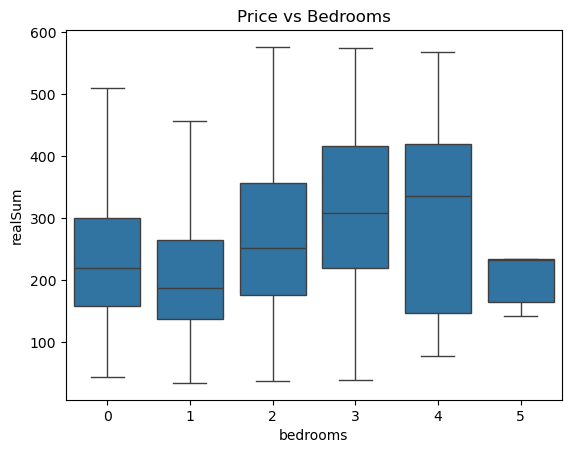

In [12]:
# price vs bedrooms, ignore rare listing that have more than 5 bedrooms
df_bedrooms = df[df['bedrooms'] <= 5]
plt.figure()
sns.boxplot(data=df_bedrooms, x='bedrooms', y='realSum', showfliers=False)
plt.title('Price vs Bedrooms')
plt.savefig('../airbnb/img/price_vs_bedrooms.png')
plt.show()

More bedrooms means a higher price

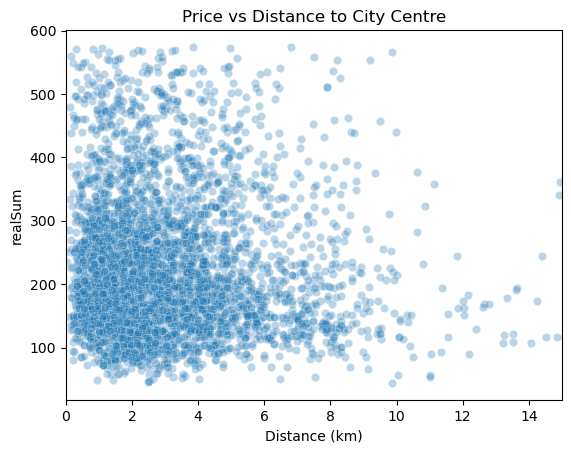

In [13]:
# price and distance to city center
sample = df.sample(4000, random_state=42)  

plt.figure()
sns.scatterplot(data=sample, x='dist', y='realSum', alpha=0.3)  
plt.title('Price vs Distance to City Centre')
plt.xlabel('Distance (km)')
plt.xlim(0, 15)   
plt.savefig('../airbnb/img/price_vs_distance.png')
plt.show()

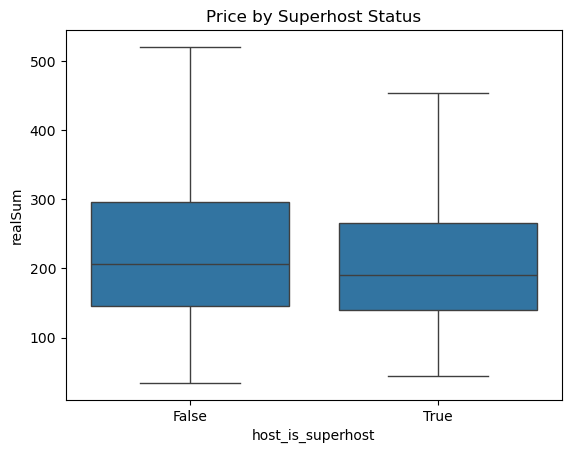

In [15]:
# superhost vs price
plt.figure()
sns.boxplot(data=df, x='host_is_superhost', y='realSum', showfliers=False)
plt.title('Price by Superhost Status')
plt.savefig('../airbnb/img/price_vs_superhost.png')
plt.show()

Superhosts don't clearly charge more than regular hosts

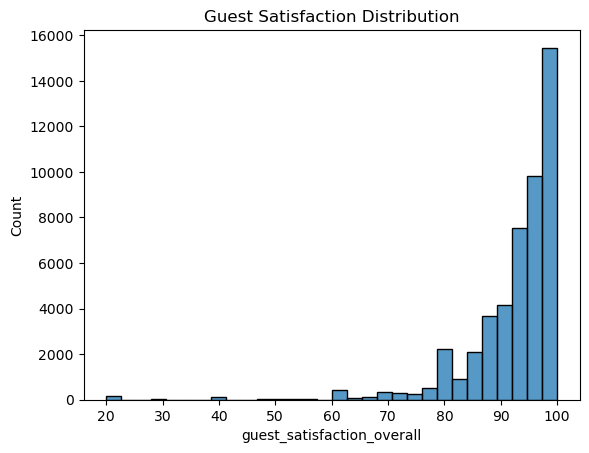

In [16]:
# guest satisfaction distribution
plt.figure()
sns.histplot(df['guest_satisfaction_overall'], bins=30)
plt.title('Guest Satisfaction Distribution')
plt.savefig('../airbnb/img/guest_satisfaction_dist.png')
plt.show()

Most listings score between 90 and 100

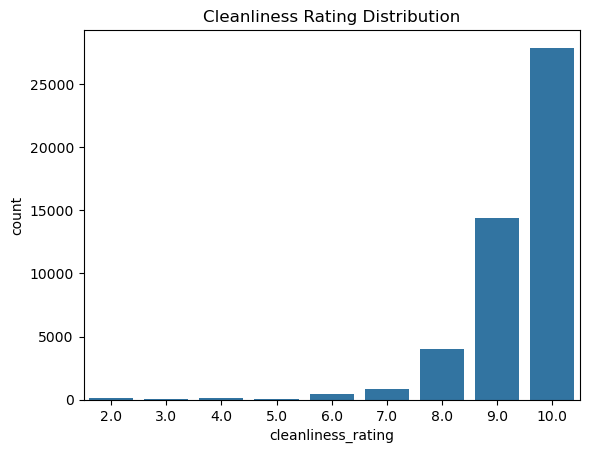

In [17]:
# cleanliness rating distribution
plt.figure()
sns.countplot(data=df, x='cleanliness_rating')
plt.title('Cleanliness Rating Distribution')
plt.savefig('../airbnb/img/cleanliness_rating_dist.png')
plt.show()

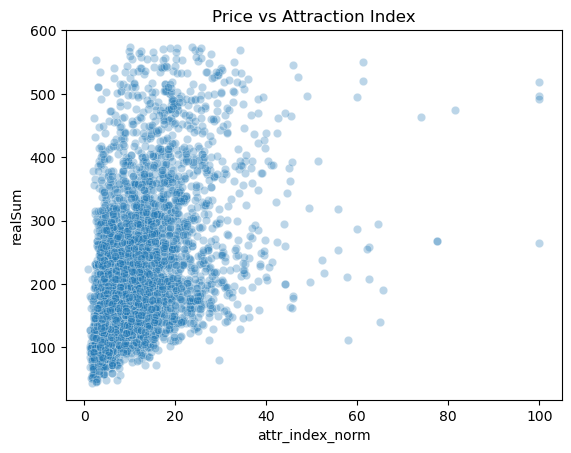

In [18]:
# price vs attraction index
sample = df.sample(4000, random_state=42)

plt.figure()
sns.scatterplot(data=sample, x='attr_index_norm', y='realSum', alpha=0.3)
plt.title('Price vs Attraction Index')
plt.savefig('../airbnb/img/price_vs_attraction_index.png')
plt.show()

Being near more attractions is tend to a slightly higher price

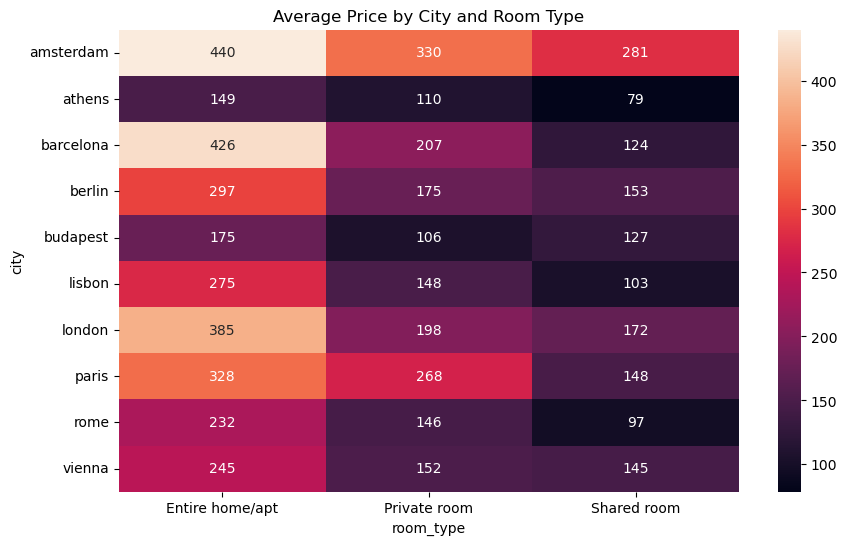

In [20]:
# avg price by city and room type
pivot = df.pivot_table(index='city', columns='room_type', values='realSum', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.0f')
plt.title('Average Price by City and Room Type')
plt.savefig('../airbnb/img/price_city_roomtype_heatmap.png')
plt.show()

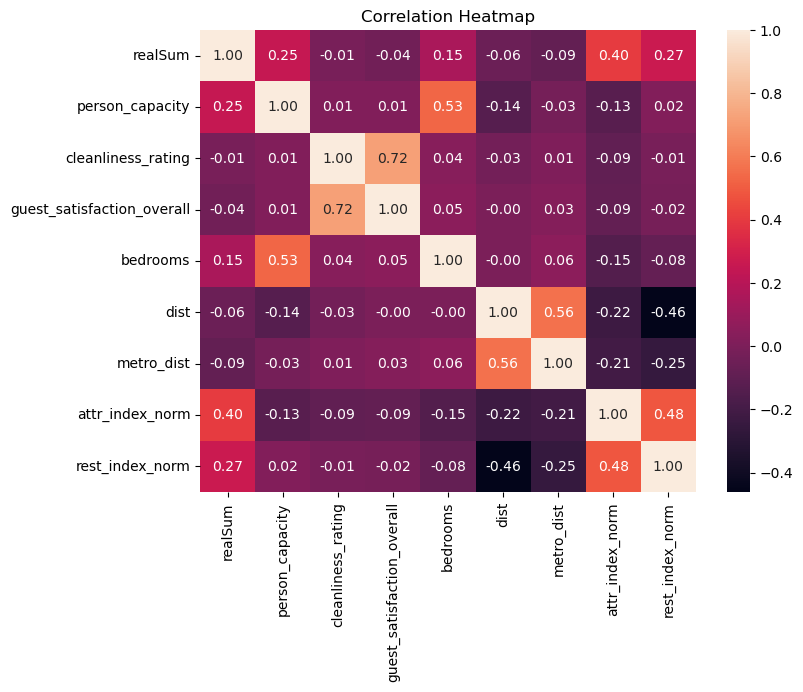

In [22]:
# correlation heatmap
numeric_cols = ['realSum', 'person_capacity', 'cleanliness_rating',
                'guest_satisfaction_overall', 'bedrooms', 'dist',
                'metro_dist', 'attr_index_norm', 'rest_index_norm']

corr = df[numeric_cols].corr() 
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f') 
plt.title('Correlation Heatmap')
plt.savefig('../airbnb/img/heatmap.png')
plt.show()

Price correlates most with person_capacity and bedrooms, attraction scores barely correlate with price directly.

The most consistent price drivers are room type, person capacity, bedrooms, and city. Location-based features (dist, attraction/restaurant indices) show real but weaker relationships. superhost, cleanliness, satisfaction show little direct price effect in this dataset.

# ML models

Predict listing price (realSum) and compare 3 models: Linear Regression, Decision Tree, and Random Forest. Evaluate with MAE, RMSE, and R².

In [23]:
from sklearn.model_selection import train_test_split     
from sklearn.linear_model import LinearRegression         
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor       
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Prepare the features

In [24]:
# room_type, city, and price_period are text categories, turn them into 0/1 columns with pd.get_dummies(). boolean columns also get converted to 0/1 
features = ['person_capacity', 'cleanliness_rating', 'guest_satisfaction_overall',
            'bedrooms', 'dist', 'metro_dist', 'attr_index_norm', 'rest_index_norm',
            'room_type', 'city', 'price_period',
            'host_is_superhost', 'multi', 'biz']

X = df[features].copy()  
X['host_is_superhost'] = X['host_is_superhost'].astype(int)   

X = pd.get_dummies(X, columns=['room_type', 'city', 'price_period']) 

y = df['realSum'] 

X.shape

(48045, 26)

#### train/test split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (38436, 26) Test: (9609, 26)


#### Linear Regression, Decision Tree, and Random Forest

In [26]:
# linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)          
lr_pred = lr.predict(X_test)      

#descision tree
dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

#random forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Models trained")

Models trained


In [27]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)         
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   
    r2 = r2_score(y_true, y_pred)                           
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

results = [
    evaluate(y_test, lr_pred, 'Linear Regression'),
    evaluate(y_test, dt_pred, 'Decision Tree'),
    evaluate(y_test, rf_pred, 'Random Forest'),
]

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)  
results_df


,Model,MAE,RMSE,R2
2,Random Forest,45.50,62.13,0.6912
1,Decision Tree,52.51,71.59,0.5901
0,Linear Regression,55.45,73.14,0.5721


As seen in R2 score random forest performed best

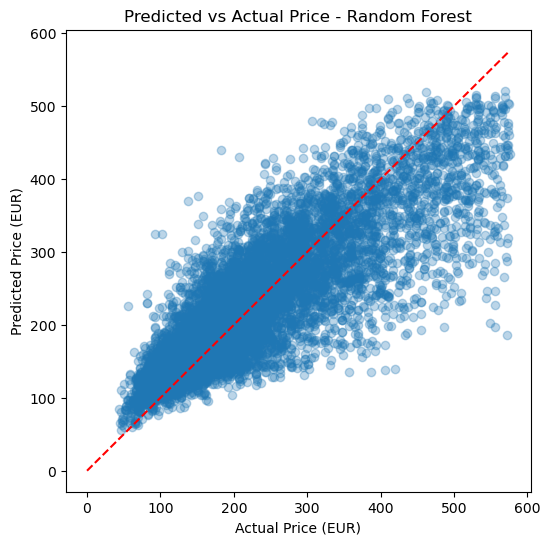

In [28]:
# predicted vs actual reandom forest 
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.3)  
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--') 
plt.xlabel('Actual Price (EUR)')
plt.ylabel('Predicted Price (EUR)')
plt.title('Predicted vs Actual Price - Random Forest')
plt.savefig('../airbnb/img/predicted_vs_actual.png')
plt.show()

Points near the red line mean the prediction was close to the real price. The model does well for mid-range prices and gets less accurate for more expensive listings.

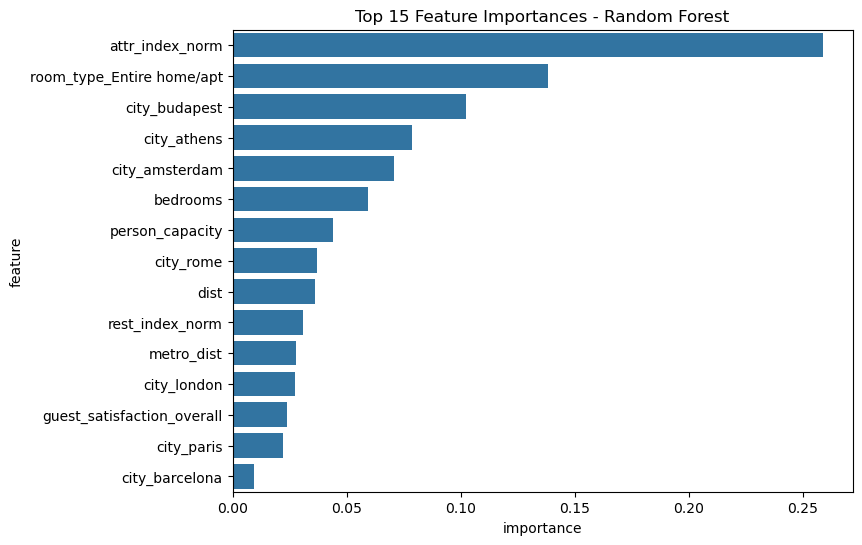

In [29]:
# feature importance of the models using .feature_importances_ built-in property in sklearn
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_  
}).sort_values('importance', ascending=False).head(15)  

plt.figure(figsize=(8, 6))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('Top 15 Feature Importances - Random Forest')
plt.savefig('../airbnb/img/feature_importance.png')
plt.show()

room type, person capacity, and distance to city centre are the strongest predictors

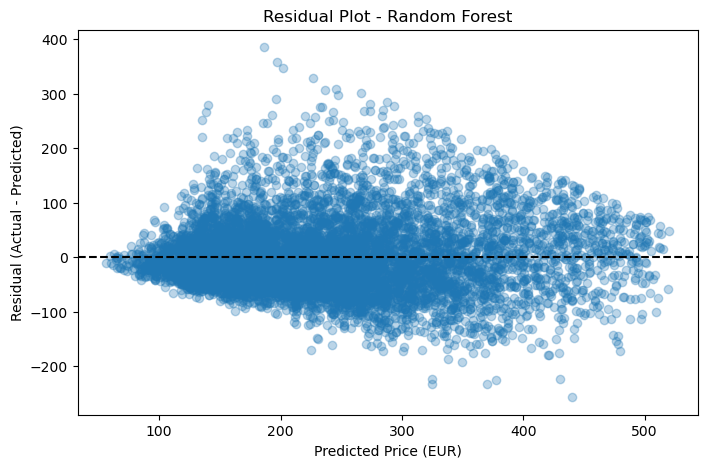

In [30]:
# residual plot
residuals = y_test - rf_pred 
plt.figure(figsize=(8, 5))
plt.scatter(rf_pred, residuals, alpha=0.3)
plt.axhline(0, color='black', linestyle='--')  
plt.xlabel('Predicted Price (EUR)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot - Random Forest')
plt.savefig('../airbnb/img/residual_plot.png')
plt.show()

residuals spread out more at higher predicted prices, meaning the model is less accurate for expensive listings